# 02 — Deep Learning: 1D CNN Classifier + Autoencoder Anomaly Detector

Phase 1's classical baseline hit ~98% accuracy on the load-0-only 10-class problem — too easy
to be a meaningful deep-learning comparison. Phase 2 instead uses the **full cross-condition
CWRU dataset** (all 10 classes, all 4 loads, downloaded in this phase — see
[docs/datasets.md](../docs/datasets.md)) with a genuine held-out-load split: train on loads
0-2, test entirely on the unseen load 3.

Two models:
- **1D CNN** — supervised, raw-signal classifier (no hand-engineered features)
- **Convolutional autoencoder** — unsupervised, trained on `Normal` windows only, flags faults
  via reconstruction error

Plus the Phase 1 classical baseline (Random Forest / SVM), retrained on the *same*
cross-condition split, as an apples-to-apples reference point.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

from src.data.cwru import build_windowed_dataset, SAMPLE_RATE_HZ
from src.data.features import build_feature_matrix
from src.data.torch_utils import WindowDataset, compute_train_stats
from src.models.baseline import time_contiguous_split, train_random_forest, train_svm, evaluate
from src.models.cnn import Cnn1D, train_cnn, predict
from src.models.autoencoder import ConvAutoencoder, train_autoencoder, reconstruction_errors

CWRU_DIR = Path.cwd().parent / "data" / "raw" / "cwru"
WINDOW_SIZE = 2048
TEST_LOAD = 3
torch.manual_seed(42)
np.random.seed(42)


## Load, window, and split by held-out load

In [2]:
windows, labels, loads, file_ids = build_windowed_dataset(CWRU_DIR, window_size=WINDOW_SIZE)
print("total windows:", windows.shape)
print(pd.crosstab(labels, loads))


total windows: (2953, 2048)
col_0     0    1    2    3
row_0                     
B007     59   59   59   59
B014     59   59   59   59
B021     59   59   59   59
IR007    59   59   59   60
IR014    59   59   59   59
IR021    59   59   59   59
Normal  119  236  236  237
OR007    59   59   59   59
OR014    59   59   59   59
OR021    59   59   59   59


In [3]:
train_mask = loads != TEST_LOAD
test_mask = loads == TEST_LOAD

# carve an inner validation split out of the train loads (0-2), time-contiguous per file,
# so the held-out load-3 test set stays untouched until final evaluation
inner_train_mask, inner_val_mask = time_contiguous_split(file_ids[train_mask], test_fraction=0.15)

le = LabelEncoder()
y_all = le.fit_transform(labels)
class_names = le.classes_
print("classes:", list(class_names))


classes: [np.str_('B007'), np.str_('B014'), np.str_('B021'), np.str_('IR007'), np.str_('IR014'), np.str_('IR021'), np.str_('Normal'), np.str_('OR007'), np.str_('OR014'), np.str_('OR021')]


## 1D CNN classifier (raw signal)

In [4]:
X_train_raw = windows[train_mask][inner_train_mask]
X_val_raw = windows[train_mask][inner_val_mask]
X_test_raw = windows[test_mask]

y_train = y_all[train_mask][inner_train_mask]
y_val = y_all[train_mask][inner_val_mask]
y_test = y_all[test_mask]

train_mean, train_std = compute_train_stats(X_train_raw)

train_ds = WindowDataset(X_train_raw, y_train, train_mean, train_std)
val_ds = WindowDataset(X_val_raw, y_val, train_mean, train_std)
test_ds = WindowDataset(X_test_raw, y_test, train_mean, train_std)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

print("train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))


train: 1853 val: 331 test: 769


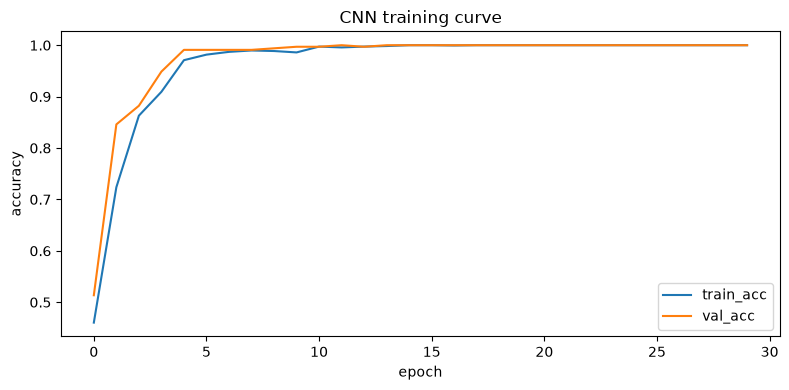

,epoch,train_loss,train_acc,val_loss,val_acc
25,25,0.006914,1.0,0.004932,1.0
26,26,0.006006,1.0,0.004191,1.0
27,27,0.005371,1.0,0.003830,1.0
28,28,0.005051,1.0,0.003491,1.0
29,29,0.004433,1.0,0.003184,1.0


In [5]:
cnn_model = Cnn1D(num_classes=len(class_names))
history = train_cnn(cnn_model, train_loader, val_loader, epochs=30, lr=1e-3)

history_df = pd.DataFrame(history)
history_df[["train_acc", "val_acc"]].plot(figsize=(8, 4), title="CNN training curve")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.tight_layout()
plt.show()
history_df.tail()


In [6]:
cnn_preds, cnn_targets = predict(cnn_model, test_loader)
cnn_pred_labels = le.inverse_transform(cnn_preds)
cnn_true_labels = le.inverse_transform(cnn_targets)

print(classification_report(cnn_true_labels, cnn_pred_labels, zero_division=0))
cnn_accuracy = (cnn_preds == cnn_targets).mean()
print(f"CNN held-out-load accuracy: {cnn_accuracy:.3f}")


              precision    recall  f1-score   support

        B007       1.00      1.00      1.00        59
        B014       0.48      1.00      0.65        59
        B021       0.00      0.00      0.00        59
       IR007       1.00      1.00      1.00        60
       IR014       1.00      0.93      0.96        59
       IR021       1.00      1.00      1.00        59
      Normal       1.00      1.00      1.00       237
       OR007       1.00      1.00      1.00        59
       OR014       1.00      1.00      1.00        59
       OR021       1.00      1.00      1.00        59

    accuracy                           0.92       769
   macro avg       0.85      0.89      0.86       769
weighted avg       0.88      0.92      0.89       769

CNN held-out-load accuracy: 0.918


## Classical baseline on the same cross-condition split (fair comparison)

In [7]:
features_df = build_feature_matrix(windows, fs=SAMPLE_RATE_HZ)

X_train_feat = features_df[train_mask].reset_index(drop=True)[inner_train_mask].reset_index(drop=True)
X_test_feat = features_df[test_mask].reset_index(drop=True)
y_train_feat = labels[train_mask][inner_train_mask]
y_test_feat = labels[test_mask]

rf_model = train_random_forest(X_train_feat, y_train_feat)
rf_results = evaluate(rf_model, X_test_feat, y_test_feat)
print("Random Forest (held-out load 3):")
print(rf_results["report"])

svm_model = train_svm(X_train_feat, y_train_feat)
svm_results = evaluate(svm_model, X_test_feat, y_test_feat)
print("SVM (held-out load 3):")
print(svm_results["report"])


Random Forest (held-out load 3):
              precision    recall  f1-score   support

        B007       1.00      0.98      0.99        59
        B014       0.87      0.98      0.92        59
        B021       0.88      1.00      0.94        59
       IR007       1.00      1.00      1.00        60
       IR014       1.00      0.86      0.93        59
       IR021       1.00      1.00      1.00        59
      Normal       1.00      1.00      1.00       237
       OR007       1.00      1.00      1.00        59
       OR014       1.00      0.88      0.94        59
       OR021       1.00      1.00      1.00        59

    accuracy                           0.98       769
   macro avg       0.97      0.97      0.97       769
weighted avg       0.98      0.98      0.98       769

SVM (held-out load 3):
              precision    recall  f1-score   support

        B007       1.00      0.98      0.99        59
        B014       0.32      1.00      0.48        59
        B021       0.9

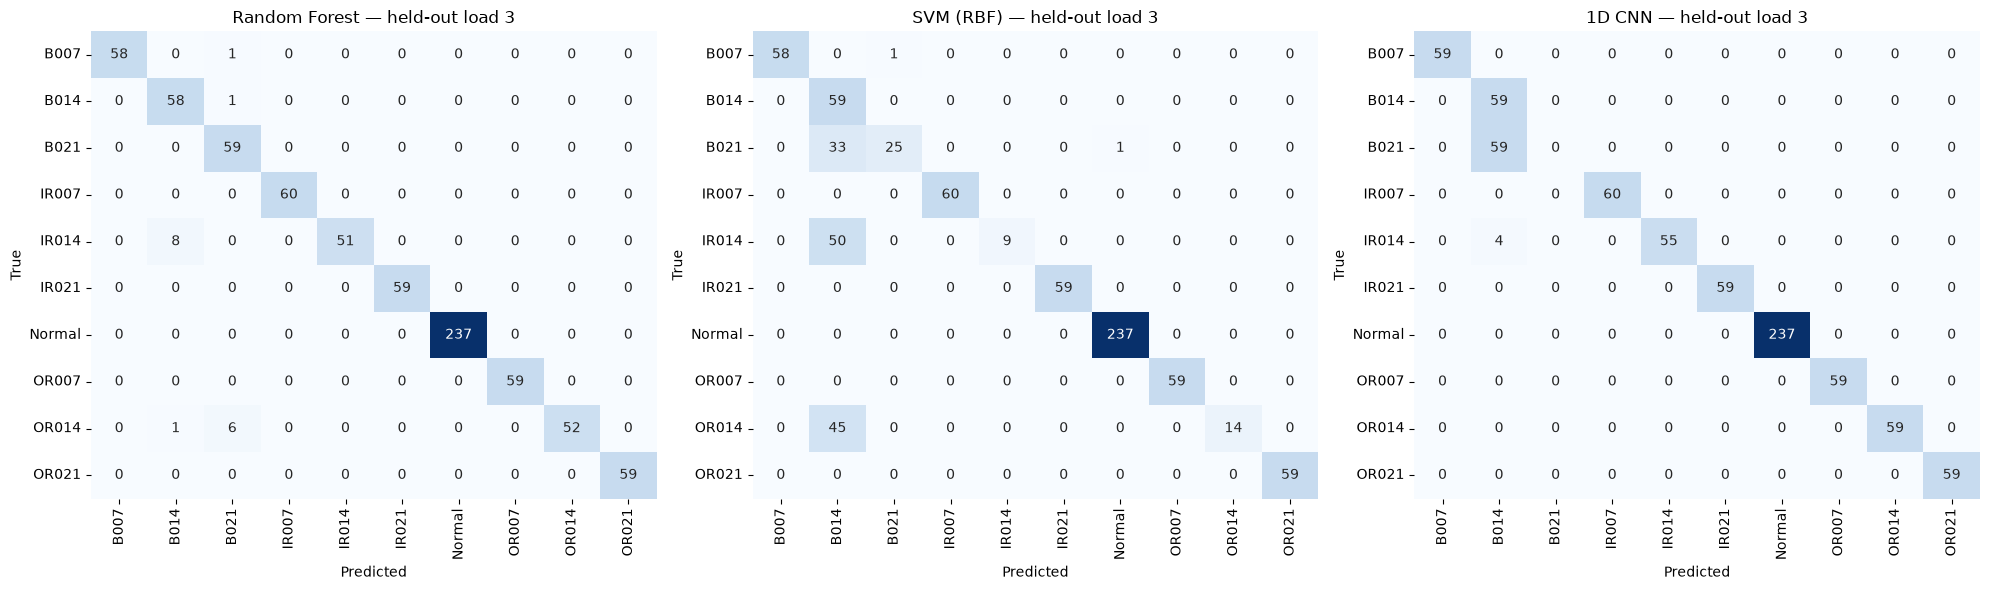

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cnn_cm = confusion_matrix(cnn_true_labels, cnn_pred_labels, labels=class_names)
for ax, cm, title in [
    (axes[0], rf_results["confusion_matrix"], "Random Forest"),
    (axes[1], svm_results["confusion_matrix"], "SVM (RBF)"),
    (axes[2], cnn_cm, "1D CNN"),
]:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,
                yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f"{title} — held-out load 3")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "phase2_confusion_matrices.png", dpi=150)
plt.show()


## Convolutional autoencoder — unsupervised anomaly detection

Trained only on `Normal` windows from the train loads (0-2). At test time (held-out load 3,
all classes), reconstruction error should be low for `Normal` windows and high for faulty
windows the model never saw the shape of.


In [9]:
normal_mask_full = labels == "Normal"
ae_train_mask = normal_mask_full & train_mask
ae_file_ids = file_ids[ae_train_mask]
ae_inner_train, ae_inner_val = time_contiguous_split(ae_file_ids, test_fraction=0.15)

X_ae_train_raw = windows[ae_train_mask][ae_inner_train]
X_ae_val_raw = windows[ae_train_mask][ae_inner_val]

ae_mean, ae_std = compute_train_stats(X_ae_train_raw)
ae_train_ds = WindowDataset(X_ae_train_raw, np.zeros(len(X_ae_train_raw)), ae_mean, ae_std)
ae_val_ds = WindowDataset(X_ae_val_raw, np.zeros(len(X_ae_val_raw)), ae_mean, ae_std)
ae_train_loader = DataLoader(ae_train_ds, batch_size=64, shuffle=True)
ae_val_loader = DataLoader(ae_val_ds, batch_size=64)

print("AE train:", len(ae_train_ds), "AE val:", len(ae_val_ds))


AE train: 503 AE val: 88


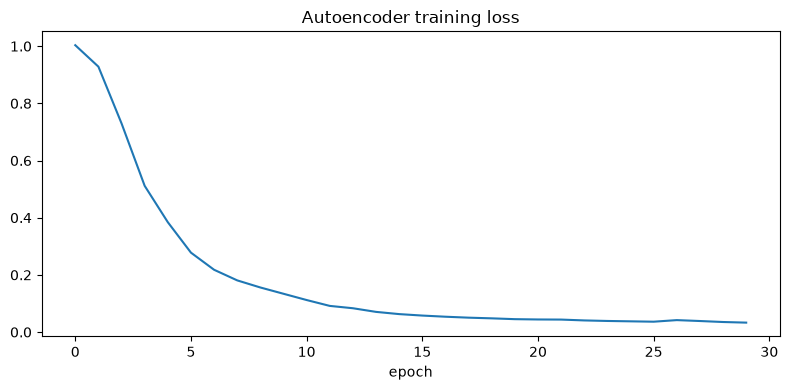

In [10]:
ae_model = ConvAutoencoder()
ae_history = train_autoencoder(ae_model, ae_train_loader, epochs=30, lr=1e-3)
pd.DataFrame(ae_history)["train_loss"].plot(figsize=(8, 4), title="Autoencoder training loss")
plt.xlabel("epoch")
plt.tight_layout()
plt.show()


In [11]:
# reconstruction error on ALL held-out-load-3 windows (normal + every fault type)
X_test_ae_ds = WindowDataset(X_test_raw, np.zeros(len(X_test_raw)), ae_mean, ae_std)
test_ae_loader = DataLoader(X_test_ae_ds, batch_size=64)
test_errors = reconstruction_errors(ae_model, test_ae_loader)

is_fault_test = (labels[test_mask] != "Normal").astype(int)
auroc = roc_auc_score(is_fault_test, test_errors)
print(f"Autoencoder anomaly-detection AUROC (held-out load 3): {auroc:.3f}")

# threshold = 95th percentile of held-out AE-validation (normal) reconstruction error
val_errors = reconstruction_errors(ae_model, ae_val_loader)
threshold = np.percentile(val_errors, 95)
predicted_anomaly = (test_errors > threshold).astype(int)
detection_accuracy = (predicted_anomaly == is_fault_test).mean()
print(f"Threshold (95th pct of val-normal error): {threshold:.5f}")
print(f"Detection accuracy at that threshold: {detection_accuracy:.3f}")


Autoencoder anomaly-detection AUROC (held-out load 3): 1.000
Threshold (95th pct of val-normal error): 0.03951
Detection accuracy at that threshold: 0.805


In [12]:
print(f"normal test error: mean={test_errors[is_fault_test == 0].mean():.4f}, "
      f"max={test_errors[is_fault_test == 0].max():.4f}")
print(f"fault test error:  mean={test_errors[is_fault_test == 1].mean():.4f}, "
      f"min={test_errors[is_fault_test == 1].min():.4f}")


normal test error: mean=0.0408, max=0.0513
fault test error:  mean=26.3489, min=0.9141


**The AUROC=1.0 / 80.5%-accuracy gap, explained:** normal-load-3 reconstruction error
(mean 0.041, max 0.051) and fault error (min 0.914) sit an order of magnitude apart - by rank,
separation is perfect, hence AUROC=1.0. But the fixed threshold (0.0395) was calibrated as the
95th percentile of `Normal` windows from the *train* loads (0-2), and load-3's own `Normal`
baseline reconstruction error runs slightly higher across its whole distribution (mean 0.041 >
threshold 0.0395) - a small covariate shift across operating conditions pushes roughly half of
the held-out-load `Normal` windows just over a threshold tuned on a different load. This is a
realistic problem for unsupervised deployment: you can't peek at test-time fault examples to
recalibrate, only at your own `Normal` validation data, and that data may not perfectly
represent every future operating condition. Worth reopening in Phase 4/5 with either a
per-load-adaptive threshold or by feeding load/RPM as an auxiliary input.


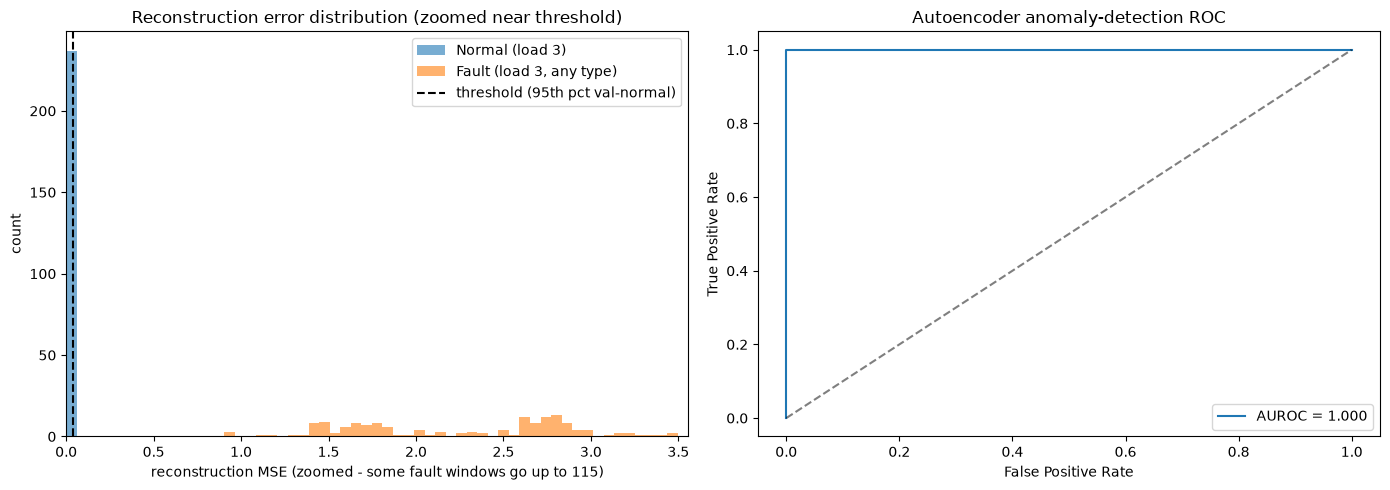

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# zoom the x-axis to where normal/threshold/near-threshold faults actually sit - a few
# extreme fault windows have MSE up to ~100x the threshold and would otherwise squash
# the informative region into invisibility
zoom_xmax = max(threshold * 4, np.percentile(test_errors[is_fault_test == 1], 10) * 2)
bins = np.linspace(0, zoom_xmax, 60)  # fine bins over the zoomed range, not the full 0-115 span

axes[0].hist(test_errors[is_fault_test == 0], bins=bins, alpha=0.6, label="Normal (load 3)")
axes[0].hist(test_errors[is_fault_test == 1], bins=bins, alpha=0.6, label="Fault (load 3, any type)")
axes[0].axvline(threshold, color="k", linestyle="--", label="threshold (95th pct val-normal)")
axes[0].set_xlim(0, zoom_xmax)
axes[0].set_xlabel("reconstruction MSE (zoomed - some fault windows go up to "
                    f"{test_errors[is_fault_test == 1].max():.0f})")
axes[0].set_ylabel("count")
axes[0].set_title("Reconstruction error distribution (zoomed near threshold)")
axes[0].legend()

fpr, tpr, _ = roc_curve(is_fault_test, test_errors)
axes[1].plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Autoencoder anomaly-detection ROC")
axes[1].legend()

fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "phase2_autoencoder_roc.png", dpi=150)
plt.show()


## Summary comparison

In [14]:
summary = pd.DataFrame([
    {"model": "Random Forest (classical)", "task": "10-class classification", "metric": "accuracy",
     "value": rf_results["report_dict"]["accuracy"]},
    {"model": "SVM (classical)", "task": "10-class classification", "metric": "accuracy",
     "value": svm_results["report_dict"]["accuracy"]},
    {"model": "1D CNN (deep learning)", "task": "10-class classification", "metric": "accuracy",
     "value": cnn_accuracy},
    {"model": "Conv Autoencoder (deep learning)", "task": "binary anomaly detection", "metric": "AUROC",
     "value": auroc},
])
summary


,model,task,metric,value
0,Random Forest (classical),10-class classification,accuracy,0.977893
1,SVM (classical),10-class classification,accuracy,0.830949
2,1D CNN (deep learning),10-class classification,accuracy,0.918075
3,Conv Autoencoder (deep learning),binary anomaly detection,AUROC,1.000000
